In [1]:

!pip install medmnist torch torchvision matplotlib scikit-learn

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import medmnist
from medmnist import PneumoniaMNIST

from torchvision import transforms
from torchvision.models import resnet18

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.1 MB/s eta 0:00:00


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [3]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = PneumoniaMNIST(split="train", transform=train_transform, download=True)
val_dataset   = PneumoniaMNIST(split="val", transform=test_transform, download=True)
test_dataset  = PneumoniaMNIST(split="test", transform=test_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.35MB/s]


In [4]:
class ResNet18_Pneumonia(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = resnet18(pretrained=False)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.fc = nn.Linear(self.model.fc.in_features, 1)

    def forward(self, x):
        return self.model(x)


In [5]:
model = ResNet18_Pneumonia().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()

        logits = model(x)                 # shape: [B, 1]
        loss = criterion(
            logits.squeeze(),             # shape: [B]
            y.squeeze()                   # shape: [B]
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.float().to(device)

            logits = model(x)
            loss = criterion(
                logits.squeeze(),
                y.squeeze()
            )

            total_loss += loss.item()

    return total_loss / len(loader)


In [7]:
num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss = eval_epoch(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )


Epoch [1/30] Train Loss: 0.1832 | Val Loss: 0.1030
Epoch [2/30] Train Loss: 0.1225 | Val Loss: 0.1304
Epoch [3/30] Train Loss: 0.1060 | Val Loss: 0.1081
Epoch [4/30] Train Loss: 0.0994 | Val Loss: 0.1188
Epoch [5/30] Train Loss: 0.0924 | Val Loss: 0.2714
Epoch [6/30] Train Loss: 0.0717 | Val Loss: 0.0747
Epoch [7/30] Train Loss: 0.0625 | Val Loss: 0.0714
Epoch [8/30] Train Loss: 0.0592 | Val Loss: 0.0594
Epoch [9/30] Train Loss: 0.0570 | Val Loss: 0.0665
Epoch [10/30] Train Loss: 0.0492 | Val Loss: 0.0610
Epoch [11/30] Train Loss: 0.0502 | Val Loss: 0.0727
Epoch [12/30] Train Loss: 0.0480 | Val Loss: 0.0674
Epoch [13/30] Train Loss: 0.0509 | Val Loss: 0.0715
Epoch [14/30] Train Loss: 0.0407 | Val Loss: 0.0640
Epoch [15/30] Train Loss: 0.0400 | Val Loss: 0.0658
Epoch [16/30] Train Loss: 0.0403 | Val Loss: 0.0611
Epoch [17/30] Train Loss: 0.0374 | Val Loss: 0.0617
Epoch [18/30] Train Loss: 0.0380 | Val Loss: 0.0608
Epoch [19/30] Train Loss: 0.0364 | Val Loss: 0.0615
Epoch [20/30] Train L

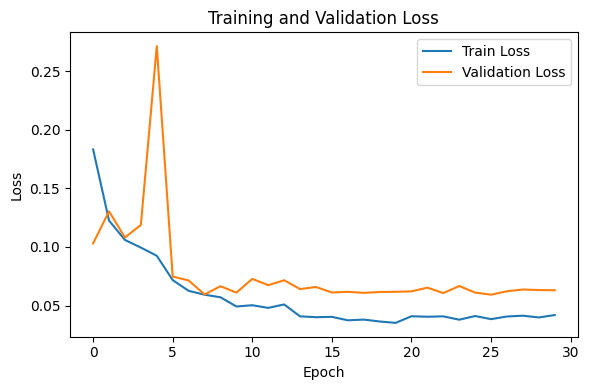

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model.eval()

y_true = []
y_prob = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.float().to(device)

        logits = model(x)
        probs = torch.sigmoid(logits.squeeze())

        y_prob.extend(probs.cpu().numpy())
        y_true.extend(y.squeeze().cpu().numpy())

import numpy as np

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1-score :", f1_score(y_true, y_pred))
print("ROC AUC  :", roc_auc_score(y_true, y_prob))


Accuracy : 0.8637820512820513
Precision: 0.8265524625267666
Recall   : 0.9897435897435898
F1-score : 0.9008168028004667
ROC AUC  : 0.9586511067280299


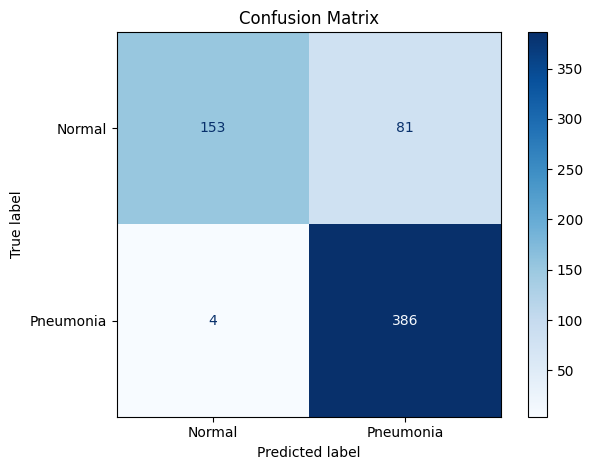

In [10]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Pneumonia"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


Number of misclassified samples: 85


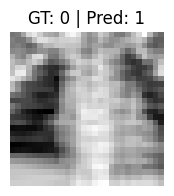

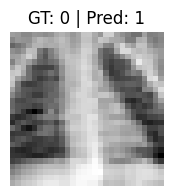

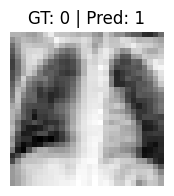

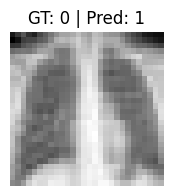

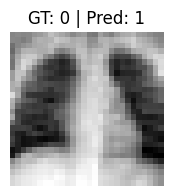

In [11]:
misclassified_indices = np.where(y_pred != y_true)[0]

print(f"Number of misclassified samples: {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img, label = test_dataset[idx]

    plt.figure(figsize=(2,2))
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"GT: {label.item()} | Pred: {y_pred[idx]}")
    plt.axis("off")
    plt.show()


In [12]:
torch.save(model.state_dict(), "resnet18_pneumonia.pth")
print("Model saved as resnet18_pneumonia.pth")


Model saved as resnet18_pneumonia.pth


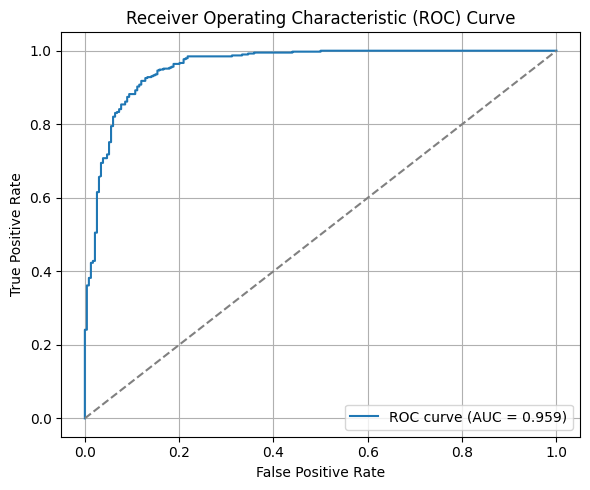

In [13]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
